In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

ERROR! Session/line number was not unique in database. History logging moved to new session 45


ValueError: Name tf.RaggedTensorSpec has already been registered for class tensorflow.python.ops.ragged.ragged_tensor.RaggedTensorSpec.

In [ ]:
"""df_train = pd.read_csv("data/fraudTrain.csv", sep=",",index_col="trans_date_trans_time")
df_test = pd.read_csv("data/fraudTest.csv", sep=",",index_col="trans_date_trans_time")"""

In [4]:
df = pd.read_csv("data/fraudTrain.csv", sep=",")

FileNotFoundError: [Errno 2] No such file or directory: 'data/fraudTrain.csv'

In [291]:
df.sample(10)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
540361,540361,2019-08-19 14:31:45,4969856774088583,fraud_Feil-Morar,health_fitness,5.64,Jacqueline,Prince,F,27823 Andrew Underpass Suite 948,...,29.9975,-90.2146,137067,Advertising account planner,1951-12-04,ddbdb7f205a5dc5f4587fec2f296a5ad,1345386705,30.752684,-89.743465,0
675,675,2019-01-01 08:49:29,630484879808,fraud_McGlynn-Jaskolski,misc_pos,36.62,Ian,Patton,M,8088 Sherman Radial Suite 689,...,36.4992,-120.0936,123,Early years teacher,1973-02-07,6458bd33847734ea1c5075edce6ef805,1325407769,35.590437,-120.030031,0
903362,903362,2019-12-27 20:31:10,6550399784335736,fraud_Rempel Inc,shopping_net,9.05,Harry,Mckee,M,95351 Sullivan Viaduct Apt. 239,...,26.9379,-82.2388,79008,Quantity surveyor,1984-08-31,cd6edbb77ef9110fa45a43b520a4720e,1356640270,27.149330,-81.397060,0
729313,729313,2019-11-08 00:44:01,6506116513503136,"fraud_Schoen, Kuphal and Nitzsche",grocery_pos,185.84,Kimberly,Rice,F,63991 Destiny Rue Apt. 651,...,32.2768,-95.3031,144160,Sports development officer,1984-05-04,02811b12af1bf50ea9307523aaff759e,1352335441,31.409731,-94.333568,0
373698,373698,2019-06-22 04:24:43,213195754007681,"fraud_Mosciski, Gislason and Mertz",grocery_pos,127.61,Zachary,Allen,M,69252 Oconnor Alley Apt. 153,...,41.2001,-92.1354,568,Commercial horticulturist,1969-07-24,b41ef40aae2d450161c5a5b9344e2663,1340339083,41.615239,-92.327338,0
1101237,1101237,2020-04-03 05:07:18,4301028321766222513,fraud_Beier-Hyatt,shopping_pos,124.15,Joe,Howard,M,109 Brian Lights Apt. 504,...,40.6025,-80.3863,198,Secretary/administrator,1978-10-26,dd6d91d2bf50dec3b55eded1adcada29,1364965638,40.000169,-80.238405,0
936452,936452,2020-01-07 16:48:44,213153151785052,fraud_Kassulke PLC,shopping_net,6.79,Rebecca,Conley,F,181 Moreno Light Apt. 215,...,45.4963,-89.7273,9594,Seismic interpreter,1997-11-23,2541209effdfd6bfb3b3dec216d7ff2e,1357577324,46.209617,-89.083010,0
1113217,1113217,2020-04-07 19:56:50,4294040533480516,fraud_Herzog Ltd,misc_pos,69.38,Gail,Weaver,F,979 Stewart Lake,...,33.4130,-81.6900,2206,Biomedical scientist,1986-12-31,40d19b81433b701e895bc26df4c4cb04,1365364610,32.835868,-82.548687,0
150513,150513,2019-03-22 12:45:34,3521417320836166,fraud_Ratke and Sons,health_fitness,9.07,Angela,Hodges,F,08236 Kim Hill,...,39.8490,-86.2720,910148,Firefighter,1975-11-30,50f0cd585d8c927d64427f372aa034ed,1332420334,39.886825,-85.929948,0
282291,282291,2019-05-19 13:10:58,375248307838179,fraud_Crona and Sons,kids_pets,70.06,Joshua,Mendoza,M,4215 Miranda Field Suite 326,...,38.8564,-80.1580,571,Accounting technician,1967-09-16,47776589cc53f1981783f35aa6d93c1d,1337433058,38.312436,-80.524994,0


In [292]:
df['is_fraud'].value_counts(normalize=True)

is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

On constate qu'on a un dataset très deséquilibrer

In [293]:
df.dtypes

Unnamed: 0                 int64
trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

<Axes: ylabel='count'>

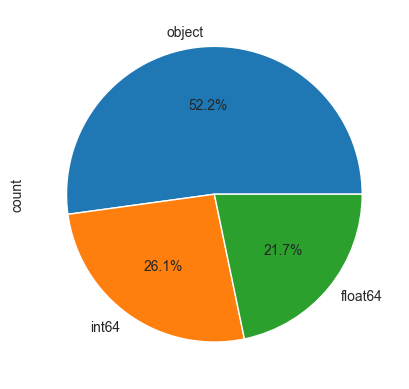

In [294]:
df.dtypes.value_counts().plot.pie(autopct='%1.1f%%')

On constate qu'il y a beaucoup de colonne de type object

In [295]:
df.duplicated().value_counts()

False    1296675
Name: count, dtype: int64

In [296]:
df.describe(include="all")

,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,city_pop,job,dob,trans_num,is_fraud
count,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06
unique,NaN,693,14,NaN,352,481,2,983,894,51,NaN,NaN,494,968,1296675,NaN
top,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,864 Reynolds Plains,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,8f7c8e4ab7f25875d753b422917c98c9,NaN
freq,NaN,4403,131659,NaN,26669,28794,709863,3123,5617,94876,NaN,NaN,9779,5636,1,NaN
mean,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,NaN,NaN,4.880067e+04,8.882444e+04,NaN,NaN,NaN,5.788652e-03
std,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,NaN,NaN,2.689322e+04,3.019564e+05,NaN,NaN,NaN,7.586269e-02
min,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,NaN,0.000000e+00
25%,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,NaN,0.000000e+00
50%,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,NaN,0.000000e+00
75%,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,NaN,NaN,7.204200e+04,2.032800e+04,NaN,NaN,NaN,0.000000e+00


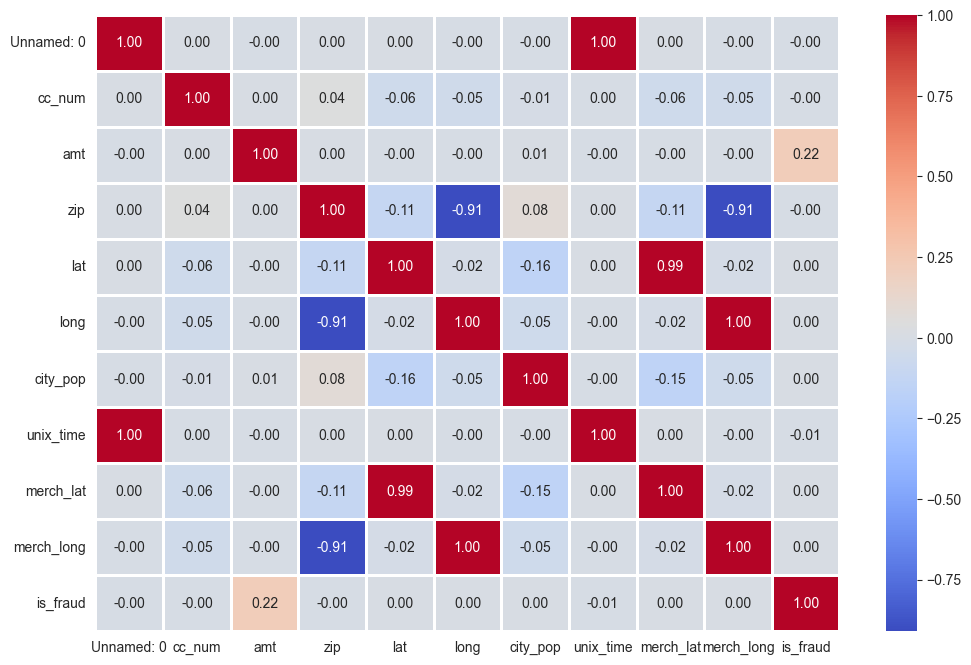

In [297]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
#kot = corr[(corr !=1.000) & ((corr >=0.4) | (corr <=(-0.2)))]
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

In [298]:
df.drop(["unix_time","merch_lat","merch_long","lat","long",'Unnamed: 0','trans_num','cc_num','last','first'], axis=1, inplace=True)

In [299]:
df.describe(include='all')

,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,city_pop,job,dob,trans_num,is_fraud
count,1.296675e+06,1296675,1296675,1.296675e+06,1296675,1296675,1296675,1296675,1296675,1296675,1.296675e+06,1.296675e+06,1296675,1296675,1296675,1.296675e+06
unique,NaN,693,14,NaN,352,481,2,983,894,51,NaN,NaN,494,968,1296675,NaN
top,NaN,fraud_Kilback LLC,gas_transport,NaN,Christopher,Smith,F,864 Reynolds Plains,Birmingham,TX,NaN,NaN,Film/video editor,1977-03-23,8f7c8e4ab7f25875d753b422917c98c9,NaN
freq,NaN,4403,131659,NaN,26669,28794,709863,3123,5617,94876,NaN,NaN,9779,5636,1,NaN
mean,4.171920e+17,NaN,NaN,7.035104e+01,NaN,NaN,NaN,NaN,NaN,NaN,4.880067e+04,8.882444e+04,NaN,NaN,NaN,5.788652e-03
std,1.308806e+18,NaN,NaN,1.603160e+02,NaN,NaN,NaN,NaN,NaN,NaN,2.689322e+04,3.019564e+05,NaN,NaN,NaN,7.586269e-02
min,6.041621e+10,NaN,NaN,1.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,1.257000e+03,2.300000e+01,NaN,NaN,NaN,0.000000e+00
25%,1.800429e+14,NaN,NaN,9.650000e+00,NaN,NaN,NaN,NaN,NaN,NaN,2.623700e+04,7.430000e+02,NaN,NaN,NaN,0.000000e+00
50%,3.521417e+15,NaN,NaN,4.752000e+01,NaN,NaN,NaN,NaN,NaN,NaN,4.817400e+04,2.456000e+03,NaN,NaN,NaN,0.000000e+00
75%,4.642255e+15,NaN,NaN,8.314000e+01,NaN,NaN,NaN,NaN,NaN,NaN,7.204200e+04,2.032800e+04,NaN,NaN,NaN,0.000000e+00


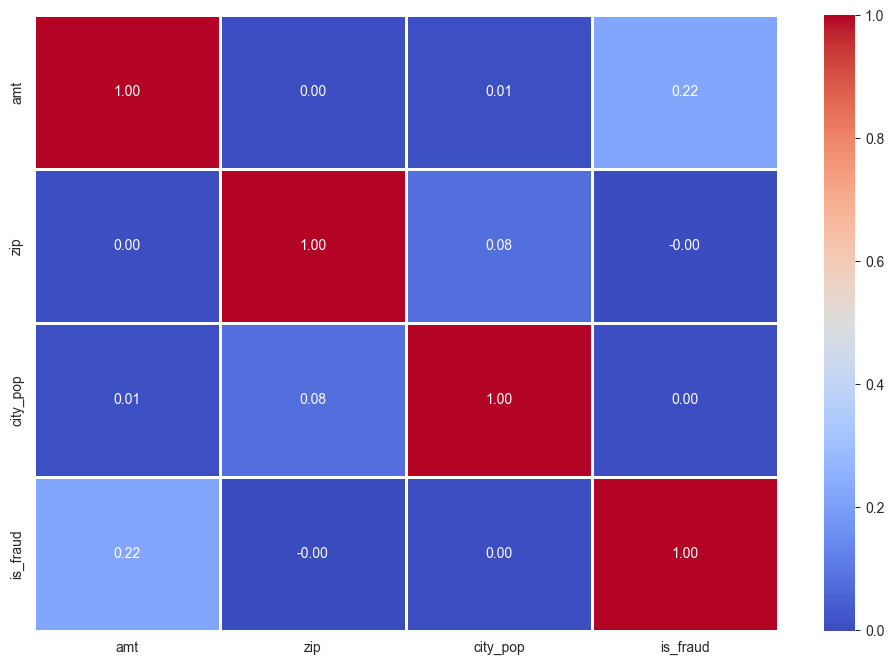

In [300]:
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=1,
            )
plt.show()

In [301]:
df.sample(5)

,trans_date_trans_time,merchant,category,amt,first,last,gender,street,city,state,zip,city_pop,job,dob,is_fraud
722775,2019-11-04 14:30:07,"fraud_Bins, Balistreri and Beatty",shopping_pos,20.42,Jackie,Davis,F,1898 Parker Fork Apt. 057,Redford,MO,63665,241,Investment analyst,1974-10-27,0
957723,2020-01-20 01:30:52,fraud_Schumm PLC,shopping_net,83.83,Stanley,Dickson,M,078 Alex Fields,Smock,PA,15480,1946,Charity fundraiser,1990-06-21,0
688472,2019-10-20 19:16:09,fraud_Cruickshank-Mills,entertainment,25.34,Joshua,Mendoza,M,4215 Miranda Field Suite 326,Tallmansville,WV,26237,571,Accounting technician,1967-09-16,0
34640,2019-01-21 12:41:37,fraud_Larkin Ltd,kids_pets,92.09,Mark,Wood,M,854 Walker Dale Suite 488,Bowdoin,ME,4287,3224,"Engineer, electronics",1997-08-22,0
156496,2019-03-24 17:36:55,fraud_Hammes-Beatty,kids_pets,64.60,Antonio,Koch,M,8738 Richard Brooks,Moab,UT,84532,9772,Location manager,1989-11-24,0


# Pretraitement

In [302]:
# Prétraitement
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler,LabelEncoder,OrdinalEncoder,OneHotEncoder
from datetime import datetime
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

In [303]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['dob'] = pd.to_datetime(df['dob'])
df['age_at_transaction'] = (df['trans_date_trans_time'] - df['dob']).dt.days / 365.25
df['age_at_transaction'] = df['age_at_transaction'].round(0).astype(int)
df['age_at_transaction']

0          31
1          41
2          57
3          52
4          33
           ..
1296670    59
1296671    41
1296672    53
1296673    40
1296674    25
Name: age_at_transaction, Length: 1296675, dtype: int64

<Axes: ylabel='Frequency'>

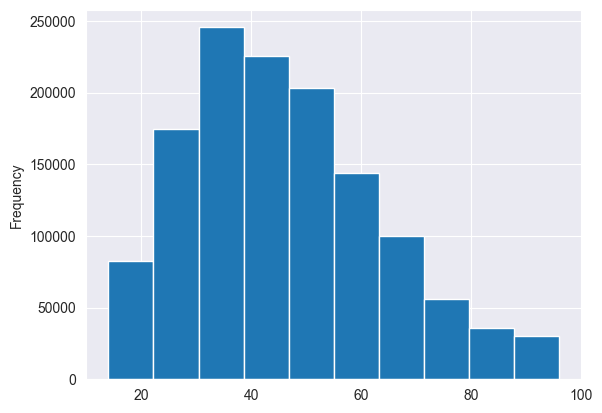

In [304]:
df['age_at_transaction'].plot(kind='hist')

In [305]:
df.drop(["dob"], axis=1, inplace=True)

In [306]:
df.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'first', 'last',
       'gender', 'street', 'city', 'state', 'zip', 'city_pop', 'job',
       'is_fraud', 'age_at_transaction'],
      dtype='object')

In [307]:
df.sample(4)

,trans_date_trans_time,merchant,category,amt,first,last,gender,street,city,state,zip,city_pop,job,is_fraud,age_at_transaction
1043457,2020-03-09 00:36:25,fraud_Collier Inc,grocery_net,64.10,Tammy,Ayers,F,1652 James Mews,Hinckley,OH,44233,7646,Medical sales representative,0,31
857639,2019-12-16 18:20:34,fraud_Kirlin and Sons,personal_care,79.86,Tara,Richards,F,4879 Cristina Station,Keisterville,PA,15449,184,Systems developer,0,74
745921,2019-11-15 14:56:31,fraud_Marvin-Lind,personal_care,97.40,Angela,Taylor,F,6343 Ramirez Skyway Apt. 518,Lakeport,CA,95453,11256,Podiatrist,0,47
1120910,2020-04-12 02:27:28,fraud_Friesen-D'Amore,gas_transport,83.14,Mary,Diaz,F,9886 Anita Drive,Fort Washakie,WY,82514,1645,Information systems manager,0,34


In [308]:
y = df["is_fraud"].astype(int)
X = df.drop(columns=["is_fraud"])

In [309]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # ✅ stratification sur la cible
)

In [310]:
numeric_features = ["amt", "zip", "city_pop", "age_at_transaction"]
#categorical_features_ord = ["Sex", "Embarked"]
categorical_features_non_ord = ["state", "city","gender","category","merchant","job"]

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

"""categorical_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])"""

categorical_non_ord_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("ordinay", OrdinalEncoder())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        #("cat_ord", categorical_ord_transformer, categorical_features_ord),
        ("cat_non_ord", categorical_non_ord_transformer, categorical_features_non_ord),
    ],
    remainder="drop"
)

# Machine Learning

In [311]:
# Modèles de Machine Learning
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, auc,roc_auc_score,precision_recall_curve

In [312]:
model_xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=10,            # ratio 99% / 1%
    subsample=0.8,                  # Sous-échantillonnage des lignes
    colsample_bytree=0.8,           # Sous-échantillonnage des colonnes
    eval_metric='aucpr',            # Optimise pour la précision-rappel
    random_state=42
)

pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", model_xgb)
])

In [313]:
pipe.fit(X_train, y_train)

D:\Etude\Master cours\NLP\NLP_python\.venv\lib\site-packages\xgboost\core.py:158: UserWarning: [17:54:32] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['amt', 'zip', 'city_pop',
                                                   'age_at_transaction']),
                                                 ('cat_non_ord',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('ordinay',
                                                                   OrdinalEncoder())]),
                                                  ['state', 'city', 'gender',
                                                   'fir...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=200, n_jobs=None,
                               num_parallel_tree=None, random_state=None, ...))])

In [314]:
X_train

,trans_date_trans_time,merchant,category,amt,first,last,gender,street,city,state,zip,city_pop,job,age_at_transaction
509059,2019-08-09 03:13:27,"fraud_Stokes, Christiansen and Sipes",grocery_net,51.71,Destiny,Lowe,F,79472 Stevens Trace Apt. 120,Hannawa Falls,NY,13647,69,Chief Executive Officer,28
395295,2019-06-29 19:56:48,fraud_Effertz LLC,entertainment,13.78,Sarah,Bishop,F,554 Mcdonald Valley Apt. 539,Meridian,TX,76665,2526,Phytotherapist,49
536531,2019-08-18 14:42:20,fraud_Kris-Padberg,shopping_pos,961.26,Sharon,Johnson,F,7202 Jeffrey Mills,Conway,WA,98238,85,"Research officer, political party",35
271001,2019-05-13 21:27:46,fraud_Ratke and Sons,health_fitness,43.68,Jeremy,Jones,M,5758 Yates Center,Vinton,CA,96135,128,Education administrator,53
532788,2019-08-17 14:15:41,fraud_Upton PLC,entertainment,33.08,Amy,Daugherty,F,852 Thomas Well Suite 339,Owensville,MO,65066,6703,Naval architect,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125527,2019-03-10 21:06:15,"fraud_Effertz, Welch and Schowalter",entertainment,19.70,Allison,Ayala,F,87665 Karen Mill Apt. 586,Fort Myers,FL,33967,224256,Paramedic,34
150047,2019-03-22 05:06:39,fraud_Pacocha-Bauch,shopping_pos,123.45,Christian,Roman,M,495 Fisher Throughway,Grand Junction,TN,38039,1804,Clothing/textile technologist,44
1151888,2020-04-25 18:11:52,fraud_Abernathy and Sons,food_dining,64.98,Jamie,Carr,F,55363 Aaron Circle Suite 450,Lawn,PA,17041,213,Special educational needs teacher,48
547306,2019-08-22 14:59:38,fraud_Windler LLC,kids_pets,33.65,Jared,Velazquez,M,01479 Murray Circle,Matawan,NJ,7747,30770,Drilling engineer,26


In [315]:
y_pred = pipe.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nConfusion matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9786
F1-score:  0.3318

Confusion matrix:
 [[252392   5442]
 [   120   1381]]

Classification report:
               precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.20      0.92      0.33      1501

    accuracy                           0.98    259335
   macro avg       0.60      0.95      0.66    259335
weighted avg       0.99      0.98      0.99    259335



In [316]:
X_train.columns

Index(['trans_date_trans_time', 'merchant', 'category', 'amt', 'first', 'last',
       'gender', 'street', 'city', 'state', 'zip', 'city_pop', 'job',
       'age_at_transaction'],
      dtype='object')

In [317]:
model_xgb.feature_importances_

array([0.59654206, 0.01536237, 0.02375313, 0.03337405, 0.01429683,
       0.01832253, 0.03738453, 0.01849631, 0.01891255, 0.19089086,
       0.01383411, 0.01883065], dtype=float32)

In [318]:
column_names = preprocessor.get_feature_names_out()
# 2. On crée la Series avec ces noms
feat_importances = pd.Series(model_xgb.feature_importances_, index=column_names)
print(feat_importances)

num__amt                   0.596542
num__zip                   0.015362
num__city_pop              0.023753
num__age_at_transaction    0.033374
cat_non_ord__state         0.014297
cat_non_ord__city          0.018323
cat_non_ord__gender        0.037385
cat_non_ord__first         0.018496
cat_non_ord__last          0.018913
cat_non_ord__category      0.190891
cat_non_ord__merchant      0.013834
cat_non_ord__job           0.018831
dtype: float32


In [319]:
y_probs = pipe.predict_proba(X_test)[:, 1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

pr_auc = auc(recall, precision)
print(pr_auc)

0.6992612214137223


Rechercher des meilleures hyper parametre avec GridSearch

In [320]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

# Configuration de la validation croisée (essentiel pour le 1% de fraude)
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Définition de la grille de recherche
# Note : on utilise 'model__' car c'est le nom dans ta pipeline
param_grid = {
    'model__max_depth': [3, 4, 5],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__n_estimators': [100, 200, 300],
    'model__scale_pos_weight': [10, 50, 99],
    'model__subsample': [0.8],
    'model__colsample_bytree': [0.8]
}

# Scoring axé sur la précision/rappel (AUPRC)
scorer = make_scorer(average_precision_score, needs_proba=True)

# Création du GridSearch
grid_search = GridSearchCV(
    estimator=pipe,        # Ta pipeline ici
    param_grid=param_grid,
    scoring=scorer,
    cv=cv_strategy,
    n_jobs=-1,             # Utilise tous les CPU
    verbose=1
)

# Lancement sur tes données
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 81 candidates, totalling 405 fits


KeyboardInterrupt: 

In [ ]:
# Le meilleur modèle complet (avec preprocessing + meilleurs hyperparamètres)
best_pipeline = grid_search.best_estimator_

# Afficher les meilleurs réglages
print("Meilleurs paramètres trouvés :", grid_search.best_params_)